In [17]:
import pandas as pd
import numpy as np
import sys,os
from tqdm import tqdm
import sys, os
import compass
print("Using COMPASS version:", compass.__version__)

from compass.utils import plot_embed_with_label,plot_performance, score2
from compass.tokenizer import CANCER_CODE, CONCEPT
from compass import PreTrainer, FineTuner, loadcompass #, get_minmal_epoch
from compass.tokenizer import CANCER_CODE, CONCEPT

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from copy import deepcopy

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression

%matplotlib inline

def onehot(S):
    assert type(S) == pd.Series, 'Input type should be pd.Series'
    dfd = pd.get_dummies(S, dummy_na=True)
    nanidx = dfd[dfd[np.nan].astype(bool)].index
    dfd.loc[nanidx, :] = np.nan
    dfd = dfd.drop(columns=[np.nan])*1.
    cols = dfd.sum().sort_values(ascending=False).index.tolist()
    dfd = dfd[cols]
    return dfd


import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

def train_lgr_with_gridsearch(
    train_X, train_y,
    scoring='roc_auc', cv=10, n_jobs=-1, random_state=42):
    """
    1) GridSearchCV find best parameters
    2) best parameters for refit(train_X, train_y) 
    3) return: best_estimator_, best_params_, best_cv_score, final_model
    """
    # Build a pipeline: standardize -> logistic regression
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2", solver="lbfgs", class_weight="balanced",
            max_iter=1000, random_state=random_state
        ))
    ])

    # Param grid (only search C on the classifier step)
    param_grid = {
        "clf__C": np.logspace(-4, 1, 50)  # 
    }

    # Stratified CV for classification
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)

    gcv = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=scoring,
        cv=skf,
        n_jobs=n_jobs,
        refit=True,          # refit pipeline on the whole train set using best params
        verbose=0
    )
    gcv.fit(train_X, train_y)

    best_params = gcv.best_params_
    best_cv_score = gcv.best_score_
    # best_estimator = gcv.best_estimator_   # already refit on full train set

    # Optionally, extract best C for reporting
    best_C = best_params["clf__C"]

    print(f"[GridSearch] best_C={best_C:.3g}, best_{scoring}={best_cv_score:.4f}")

    # best_estimator is the final model trained on the full training data
    return gcv

Using COMPASS version: 2.0.3


In [18]:
data_path = './data/ITRP/'
df_label = pd.read_pickle(os.path.join(data_path, 'ITRP.PATIENT.TABLE'))
df_tpm = pd.read_pickle(os.path.join(data_path, 'ITRP.TPM.TABLE'))
df_tpm.shape, df_label.shape

dfcx = df_label.cancer_type.map(CANCER_CODE).to_frame('cancer_code').join(df_tpm)


In [19]:
pth = './compass_run/PT_v100/pretrainer.pt'
pretrainer = loadcompass(pth, map_location = 'cuda:0')
dfcx1 = dfcx[['cancer_code']].join(dfcx[pretrainer.feature_name])
dfe, dfg, dfc = pretrainer.extract(dfcx1,  batch_size= 128, with_gene_level = True)

100%|#####################################################################################| 9/9 [00:00<00:00, 12.53it/s]


In [20]:
s = df_label.cohort.value_counts()
large_medium_cohorts = s[s  > 30].index.tolist() #

#df_label = df_label[df_label.cohort.isin(large_cohorts)]
cohort_list = df_label.cohort.unique().tolist()


In [21]:
cohort_map = s.index + '(n=' + s.astype(str) + ')'

In [22]:
y = onehot(df_label.response_label)

In [23]:
X1 = pd.read_csv('./data/GSEA/ITRP_avg_concept_43.csv', index_col=0)
X3 = pd.read_csv('./data/GSEA/ITRP_ssGSEA_concept_43.csv', index_col=0)
X0 = dfc
X0 = X0[X0.columns[1:]]

X5 = pd.read_csv('./data/GSEA/ITRP_avg_signature_132.csv', index_col=0)
X7 = pd.read_csv('./data/GSEA/ITRP_ssGSEA_signature_132.csv', index_col=0)
X9 = dfg
X9 = X9[X9.columns[1:]]

In [24]:
def leave_one_cohort_out(cohorts):
    # Create a list of lists, each missing one element from the original list
    return [(cohorts[i], cohorts[:i] + cohorts[i+1:]) for i in range(len(cohorts))]
train_test_cohorts = leave_one_cohort_out(cohort_list)

In [25]:
Modes = ['Geometric mean from Gene TPM', 
         'ssGSEA from Gene TPM', 
         'COMPASS(Encoder-Projector)'
        ]

levels = ['concepts', 'signatures']
Xs1 = [X1, X3, X0]
Xs2 = [X5, X7, X9]

In [26]:
final_performance = []


for level, Xs in zip(levels, [Xs1, Xs2]):
    for X, mode in zip(Xs, Modes):
        
        res = []
        for test_cohort, train_cohorts in train_test_cohorts:
    
            train_cohort_name = 'Leave_%s_out' % test_cohort
            ## Get data for this cohort
            cohort_idx = df_label[df_label['cohort'].isin(train_cohorts)].index
            cohort_X = X.loc[cohort_idx]
            cohort_y = y.loc[cohort_idx]
    
            train_X = cohort_X 
            train_y = cohort_y['R'].values
    
            test_cohort_idx = df_label[df_label['cohort'] == test_cohort].index
            test_cohort_X = X.loc[test_cohort_idx]

            test_cohort_y = y.loc[test_cohort_idx]['R']
    
            gcv = train_lgr_with_gridsearch(train_X, train_y)
            test_pred_prob = gcv.best_estimator_.predict_proba(test_cohort_X)
            dfp = pd.DataFrame(test_pred_prob, index =test_cohort_y.index )
    
            dfp['train_cohort'] = train_cohort_name
            dfp['test_cohort'] = test_cohort    
            dfp['best_C'] = gcv.best_params_["clf__C"]
            dfp['mode'] = mode
            
            dfp = dfp.join(test_cohort_y)
            y_true, y_prob, y_pred = dfp['R'], dfp[1], dfp[[0, 1]].idxmax(axis=1)
            
            res.append(dfp)
    
        dfs = pd.concat(res)
        dfp = dfs.groupby(['train_cohort', 'test_cohort']).apply(lambda x:score2(x['R'], x[1], x[[0, 1]].idxmax(axis=1)))
        mode_map = dfs.groupby('train_cohort')['mode'].unique().apply(lambda x:x[0])
        c_map = dfs.groupby('train_cohort')['best_C'].unique().apply(lambda x:x[0])
        
        #roc, prc, f1, acc, mcc
        dfp = dfp.apply(pd.Series)
        dfp.columns = ['ROC', 'PRC', 'F1', 'ACC', 'MCC']
        dfp = dfp.reset_index()
        dfp['mode'] = dfp.train_cohort.map(mode_map)
        dfp['best_C'] = dfp.train_cohort.map(c_map)
        dfp['level'] = level
        final_performance.append(dfp)

dfp = pd.concat(final_performance)

[GridSearch] best_C=0.0222, best_roc_auc=0.6660
[GridSearch] best_C=0.184, best_roc_auc=0.6748
[GridSearch] best_C=0.233, best_roc_auc=0.6843
[GridSearch] best_C=0.091, best_roc_auc=0.6943
[GridSearch] best_C=0.072, best_roc_auc=0.6812
[GridSearch] best_C=0.184, best_roc_auc=0.6695
[GridSearch] best_C=0.115, best_roc_auc=0.6758
[GridSearch] best_C=0.471, best_roc_auc=0.6895
[GridSearch] best_C=0.0569, best_roc_auc=0.6886
[GridSearch] best_C=0.091, best_roc_auc=0.6899
[GridSearch] best_C=0.045, best_roc_auc=0.6628
[GridSearch] best_C=0.045, best_roc_auc=0.6848
[GridSearch] best_C=0.045, best_roc_auc=0.6941
[GridSearch] best_C=0.0176, best_roc_auc=0.6825
[GridSearch] best_C=0.146, best_roc_auc=0.6892
[GridSearch] best_C=0.0281, best_roc_auc=0.6656
[GridSearch] best_C=0.0281, best_roc_auc=0.6738
[GridSearch] best_C=0.0356, best_roc_auc=0.6751
[GridSearch] best_C=0.146, best_roc_auc=0.6860
[GridSearch] best_C=0.072, best_roc_auc=0.6934
[GridSearch] best_C=0.0222, best_roc_auc=0.6802
[GridS

In [27]:
dfp = pd.concat(final_performance)
dfp1 = dfp[dfp.test_cohort.isin(large_medium_cohorts)]

In [28]:
roc = dfp1.groupby(['level','mode', 'test_cohort']).ROC.mean().unstack().T
roc = roc.loc[large_medium_cohorts].round(3)
roc.index = roc.index.map(cohort_map)
roc_mean = roc.mean().to_frame(name='Mean').T
roc_std = roc.std().to_frame(name='Mean').T
roc_mean = roc_mean.round(3).astype(str) + '±' + roc_std.round(3).astype(str)
roc = roc.round(3).astype(str)._append(roc_mean)
roc.to_excel('./results/COMPASS_GLM_ssGSEA_ROC.xlsx')
roc

level                                concepts                               \
mode               COMPASS(Encoder-Projector) Geometric mean from Gene TPM   
IMVigor210(n=298)                       0.713                        0.645   
IMmotion150(n=165)                      0.719                        0.687   
Liu(n=107)                              0.695                        0.589   
SU2CLC1(n=102)                          0.678                         0.64   
Rose(n=89)                              0.638                        0.769   
Gide(n=73)                              0.715                        0.761   
Riaz(n=51)                              0.802                        0.546   
Kim(n=45)                               0.831                        0.927   
Allen(n=39)                             0.781                         0.66   
MGH(n=34)                               0.705                        0.708   
Mean                              0.728±0.059                  0.693±0.108   

level                                                   signatures  \
mode               ssGSEA from Gene TPM COMPASS(Encoder-Projector)   
IMVigor210(n=298)                 0.637                      0.747   
IMmotion150(n=165)                0.684                      0.747   
Liu(n=107)                        0.612                      0.736   
SU2CLC1(n=102)                    0.669                      0.721   
Rose(n=89)                        0.756                      0.707   
Gide(n=73)                        0.773                      0.748   
Riaz(n=51)                        0.568                      0.771   
Kim(n=45)                         0.912                      0.902   
Allen(n=39)                        0.68                      0.675   
MGH(n=34)                          0.67                       0.75   
Mean                        0.696±0.097                  0.75±0.06   

level                                                                 
mode               Geometric mean from Gene TPM ssGSEA from Gene TPM  
IMVigor210(n=298)                         0.662                0.652  
IMmotion150(n=165)                        0.724                0.705  
Liu(n=107)                                0.541                0.545  
SU2CLC1(n=102)                            0.668                0.656  
Rose(n=89)                                0.739                0.729  
Gide(n=73)                                0.766                0.791  
Riaz(n=51)                                0.561                0.568  
Kim(n=45)                                 0.909                0.904  
Allen(n=39)                               0.651                0.642  
MGH(n=34)                                 0.723                0.705  
Mean                                0.694±0.105           0.69±0.105

In [29]:
prc = dfp.groupby(['level','mode', 'test_cohort']).PRC.mean().unstack().T
prc = prc.loc[large_medium_cohorts].round(3)
prc.index = prc.index.map(cohort_map)
prc_mean = prc.mean().to_frame(name='Mean').T
prc_std = prc.std().to_frame(name='Mean').T
prc_mean = prc_mean.round(3).astype(str) + '±' + prc_std.round(3).astype(str)
prc = prc.round(3).astype(str)._append(prc_mean)
prc.to_excel('./results/COMPASS_GLM_ssGSEA_PRC.xlsx')
prc

level                                concepts                               \
mode               COMPASS(Encoder-Projector) Geometric mean from Gene TPM   
IMVigor210(n=298)                       0.381                        0.321   
IMmotion150(n=165)                       0.46                        0.441   
Liu(n=107)                              0.606                        0.506   
SU2CLC1(n=102)                          0.592                         0.48   
Rose(n=89)                              0.295                        0.379   
Gide(n=73)                              0.714                        0.823   
Riaz(n=51)                              0.441                        0.242   
Kim(n=45)                               0.754                        0.852   
Allen(n=39)                             0.618                        0.529   
MGH(n=34)                               0.512                        0.679   
Mean                              0.537±0.146                  0.525±0.203   

level                                                   signatures  \
mode               ssGSEA from Gene TPM COMPASS(Encoder-Projector)   
IMVigor210(n=298)                 0.308                      0.402   
IMmotion150(n=165)                0.449                      0.471   
Liu(n=107)                        0.521                      0.661   
SU2CLC1(n=102)                    0.507                      0.627   
Rose(n=89)                        0.371                      0.361   
Gide(n=73)                        0.828                      0.804   
Riaz(n=51)                        0.249                      0.378   
Kim(n=45)                          0.86                      0.859   
Allen(n=39)                       0.529                      0.604   
MGH(n=34)                         0.673                      0.701   
Mean                         0.53±0.205                0.587±0.178   

level                                                                 
mode               Geometric mean from Gene TPM ssGSEA from Gene TPM  
IMVigor210(n=298)                         0.333                0.312  
IMmotion150(n=165)                         0.46                 0.44  
Liu(n=107)                                0.456                0.468  
SU2CLC1(n=102)                            0.534                0.534  
Rose(n=89)                                 0.31                0.313  
Gide(n=73)                                0.819                0.838  
Riaz(n=51)                                0.231                0.233  
Kim(n=45)                                 0.812                 0.83  
Allen(n=39)                                0.53                0.524  
MGH(n=34)                                 0.699                0.688  
Mean                                0.518±0.205          0.518±0.212

In [30]:
palette = ['#F6C6AD', '#E59EDD', '#61CBF4']

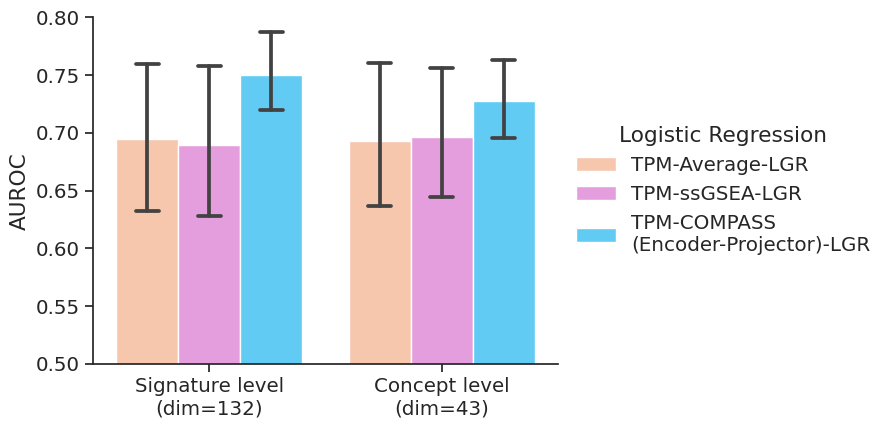

In [31]:
from statannotations.Annotator import Annotator

x='level'
y='ROC'
hue = 'mode'
labels =  ['TPM-Average-LGR',
           'TPM-ssGSEA-LGR',
          'TPM-COMPASS\n(Encoder-Projector)-LGR',      
          ]

order = ['signatures', 'concepts']
x_labelticks = ['Signature level\n(dim=132)', 'Concept level\n(dim=43)']
width = 0.5

fig, ax = plt.subplots(figsize=(6, 4.5), )
sns.barplot(data  = dfp1, x = x, hue= hue,order = order,saturation = 1,
            hue_order = Modes, capsize=0.1,  palette=palette, #width = width, errorbar = 'se', 
            #legend=False,
            y = y, ax=ax)

ax.set_ylim(0.5, 0.8)
ax.set_ylabel('AUROC')
ax.set_xlabel('')
sns.despine()

ax.tick_params(bottom=True, left=True)


handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, labels,
           title="Logistic Regression", 
           loc='center left',        
           bbox_to_anchor=(1.0, 0.5), 
           frameon=False)

ax.set_xticklabels(x_labelticks, rotation = 0)


# pairs = [
#          (('concepts', 'ssGSEA from Gene TPM'),
#           ('concepts','COMPASS(Encoder-Projector)')),
#          (('concepts', 'Geometric mean from Gene TPM'),
#           ('concepts','COMPASS(Encoder-Projector)')),

         
#          (('signatures', 'ssGSEA from Gene TPM'),
#           ('signatures','COMPASS(Encoder-Projector)')),
#          (('signatures', 'Geometric mean from Gene TPM'),
#           ('signatures','COMPASS(Encoder-Projector)')),
#         ]

# annot = Annotator(
#     ax, pairs,
#     data=dfp, x = x, y = y, hue = hue,
#     order = order, hue_order = Modes, width = width, 
#     # DO NOT pass plot='barplot'
# )
# annot.configure(
#     test='t-test_paired',                 # or 'Mann-Whitney'
#     #comparisons_correction='fdr_bh',
#     text_format='star',
#     show_test_name=False
# )
# annot.apply_and_annotate()

fig.savefig(f'./results/LGR_ROC_barplot.svg',
            bbox_inches = 'tight')

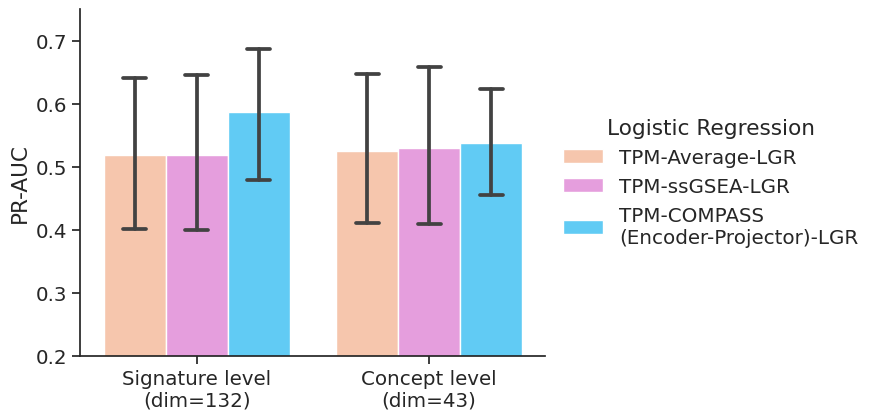

In [32]:
y='PRC'

fig, ax = plt.subplots(figsize=(6, 4.5), )
sns.barplot(data  = dfp1, x = x,  hue= hue,order = order,
            hue_order = Modes, capsize=0.1, palette=palette,saturation = 1,
            #legend=False,width = width, errorbar = 'se',
            y = y, ax=ax)

ax.set_ylim(0.2, 0.75)
ax.set_ylabel('PR-AUC')
ax.set_xlabel('')
sns.despine()

ax.tick_params(bottom=True, left=True)


handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, labels,
           title="Logistic Regression", 
           loc='center left',        
           bbox_to_anchor=(1.0, 0.5), 
           frameon=False)

ax.set_xticklabels(x_labelticks, rotation = 0)


# annot = Annotator(
#     ax, pairs,
#     data=dfp, x = x, y = y, hue = hue,
#     order = order, hue_order = Modes, width = width, 
#     # DO NOT pass plot='barplot'
# )
# annot.configure(
#     test='t-test_paired',  
#     #paired=True,  # or 'Mann-Whitney'
#     #comparisons_correction='fdr_bh',
#     text_format='star',
#     show_test_name=True
# )
# annot.apply_and_annotate()

fig.savefig(f'./results/LGR_PRC_barplot.svg',
            bbox_inches = 'tight')